# Reproducing the reference solution

For a bit of context, this notebook aims to reproduce the PINN solution in figure 1 of [the original paper](https://arxiv.org/pdf/2205.04611).

To revisit the problem, figure 1 solves the 1D wave equation

$$\frac {1} {c^2} u_{tt} = u_{xx},$$

with $c = 1$, subject to Dirichlet initial and boundary conditions $g(t, x)$:

$$g(t, x) := g^n_i = \begin{cases}
\frac {\partial}{\partial t} u(0, x) &= \tfrac{1}{10}\pi k\left(\sin((x+0.5)\pi k) - \sin((x-0.5)\pi k)\right)\\[3pt]
u(0, x) &= \tfrac{1}{10}\left(\cos((x+0.5)\pi k) + \cos((x-0.5)\pi k)\right)\\[3pt]
u(t, 0) &= \tfrac{1}{10}\left(\cos((-t+0.5)\pi k) + \cos((t-0.5)\pi k)\right)\\[3pt]
u(t, L) &= \tfrac{1}{10}\left(\cos((L-t+0.5)\pi k) + \cos((L+t-0.5)\pi k)\right)\\[3pt]
\end{cases} \text{for } k = 1, 2, 3, 4, 5,$$

where $t \in (0, 1.0),$ $x \in (-1.0, 1.0)$.

## PINN solution

In the ODIL task, we discretised our governing equation and boundary condition and formulated a discrete PDE loss from the two. ODIL borrows that notion from PINNs, which can approximate PDE solutions using a neural network via loosely enforcing the PDE and BCs/ICs through the loss. The key difference is that PINNs sample a continuous loss function. Ultimately, our hope is that a neural network $\mathcal N(t, x, \mathbf \theta)$ with parameters $\bf \theta$, can approximate our PDE

$$\mathcal{N}(t, x, \mathbf{\theta}) \approx u(t, x).$$

As mentioned, when using neural networks to solve PDEs, it is the responsibility of the loss function to enforce the PDE and boundary/ initial conditions. The network outputs data at 'collocation points': points in the domain at which the neural network approximates the PDE, which is independent of the number of parameters. Collocation points are comprised of interior points, where you differentiate the network output and check the PDE residual, and boundary/ initial points, where we check the network output against the known solution.

### Formulating the loss

We form the loss in pretty much the same way as the PINN. We could also add in a data loss, but we won't do that for this case. We require:

- A PDE residual (which we hope tends to zero, enforcing the PDE)
- A boundary/ initial condition loss (which we compare against the reference)

Our PDE residual, evaluated at the $N_p$ interior points, is

$$\mathcal{R}_\text{PDE} = \underbrace{\frac{1}{N_p}\sum_i^{N_p}\left(\left[\frac{\partial^2}{\partial t^2} - \frac{\partial^2}{\partial x^2}\right]\mathcal{N}(t_i, x_i, \mathbf{\theta})\right)^2}_{\rightarrow 0 \text{ when satisfied}}.$$

Our boundary/ intitial conditions residual is

$$\mathcal{R}_\text{cond} = \left(\mathcal{N}(t_\Gamma, x_\Gamma, \mathbf{\theta}) - g(t_\Gamma, x_\Gamma)\right)^2,$$

for the boundary/ IC domain $\Gamma$.

Our full loss, written explicitly, is thus

$$\mathcal{L}(\boldsymbol{\theta}) =
\left.
\begin{aligned}
  &\lambda_1\left(\mathcal{N}(t=0, x, \boldsymbol{\theta}) - \tfrac{1}{10}\left(\cos((x+0.5)\pi k) + \cos((x-0.5)\pi k)\right)\right)^2 \\
  &\lambda_2\left(\mathcal{N}(t, x=0, \boldsymbol{\theta}) - \tfrac{1}{10}\left(\cos((-t+0.5)\pi k) + \cos((t-0.5)\pi k)\right)\right)^2 \\
  &\lambda_3\left(\mathcal{N}(t, x=L, \boldsymbol{\theta}) - \tfrac{1}{10}\left(\cos((L-t+0.5)\pi k) + \cos((L+t-0.5)\pi k)\right)\right)^2 \\
  &\lambda_4\left(\frac{\partial}{\partial t}\mathcal{N}(t=0, x, \boldsymbol{\theta}) - \tfrac{1}{10}\pi k\left(\sin((x+0.5)\pi k) - \sin((x-0.5)\pi k)\right)\right)^2
\end{aligned}
\right\} \text{BC/ICs}
\\[6pt]
+ \left.\frac{\lambda_5}{N_p}\sum_i^{N_p}\left(\left[\frac{\partial^2}{\partial t^2} - \frac{\partial^2}{\partial x^2}\right]\mathcal{N}(t_i, x_i, \mathbf{\theta})\right)^2\right\} \text{PDE}
$$

where $k = 1, 2, 3, 4, 5$, and $\lambda_n$ are regularisation parameters.

## The network

The paper uses a simple feed forward network of 2 fully connected layers with 25 neurons each and a tanh activation. The PINN uses 8192 interior points and 768 boundary/ initial points as collocation points. Setting up the network should be straightforward, but the loss might take a bit of work. Note, to compute gradients of the neural network w.r.t. its inputs, we can use `torch.autograd.grad`.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # set the device
device

device(type='cuda')

In [3]:
def set_seed(seed=42):
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)

In [4]:
def get_exact(tt: torch.Tensor, xx: torch.Tensor) -> torch.Tensor:

    u = torch.zeros(tt.shape[0], xx.shape[0]).to(device)
    for k in range(1, 6):
        u += torch.cos((xx - tt + 0.5) * k * torch.pi)
        u += torch.cos((xx + tt - 0.5) * k * torch.pi)

    return u / 10.0

# time derivative of reference solution
# removes the need for autograd in the velocity bc
def get_exact_ut(tt: torch.Tensor, xx: torch.Tensor) -> torch.Tensor:
    u_t = torch.zeros_like(tt).to(device)
    for k in range(1, 6):
        u_t += k * torch.pi * torch.sin((xx - tt + 0.5) * k * torch.pi)
        u_t -= k * torch.pi * torch.sin((xx + tt - 0.5) * k * torch.pi)
    return u_t / 10.0

In [5]:
class PINN(nn.Module):
    def __init__(self, n_layers=2, n_neurons=25):
        super().__init__()
        activation = nn.Tanh # tanh activation function as specified

        layers = [nn.Linear(2, n_neurons), activation()] # input layer

        # build layers
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_neurons, n_neurons), nn.Tanh()]

        layers += [nn.Linear(n_neurons, 1)] # output layer

        self.net = nn.Sequential(*layers) # sequential object to encapsulate layers

    def forward(self, t, x):
        tx = torch.cat([t, x], dim=1) # shape: (N, 2)
        return self.net(tx) # shape: (N, 1)

In [19]:
# domain parameters
t_0, t_N = 0.0, 1.0
x_0, x_I = -1.0, 1.0
N, I = 25, 25

In [7]:
from torchinfo import summary

In [8]:
summary(PINN().net, input_size=(1, 2), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Sequential                               [1, 2]                    [1, 1]                    --
├─Linear: 1-1                            [1, 2]                    [1, 25]                   75
├─Tanh: 1-2                              [1, 25]                   [1, 25]                   --
├─Linear: 1-3                            [1, 25]                   [1, 25]                   650
├─Tanh: 1-4                              [1, 25]                   [1, 25]                   --
├─Linear: 1-5                            [1, 25]                   [1, 1]                    26
Total params: 751
Trainable params: 751
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

Now, we need to set up the collocation points. The paper specifies that the initial weights and positions of the collocation points are random.

In [20]:
n_interior = 8192
n_boundary = 768
n_each = n_boundary // 4 # 192 points per BC

In [42]:
def collocation_points(seed=None):
    # seed for reproducibility
    if seed is not None: set_seed(seed)
    
    # define random interior collocation points
    tx_physics = torch.rand(n_interior, 2, device=device) # generate random (t, x) points of shape (n_interior, 2)
    
    # sample and scale to domain limits
    tx_physics[:, 0] = tx_physics[:, 0] * (t_N - t_0) + t_0  # t in [t_0, t_N]
    tx_physics[:, 1] = tx_physics[:, 1] * (x_I - x_0) + x_0  # x in [x_0, x_I]
    tx_physics.requires_grad_(True) # required for autograd
    
    # decompose into t, x
    t_physics = tx_physics[:, 0:1]
    x_physics = tx_physics[:, 1:2]
    
    # define boundary/initial collocation points
    # u(t=0, x)
    x_ic = torch.rand(n_each, 1, device=device) * (x_I - x_0) + x_0
    t_ic = torch.zeros(n_each, 1, device=device)
    
    # u(t=0, x)
    t_left = torch.rand(n_each, 1, device=device) * (t_N - t_0) + t_0
    x_left = torch.zeros(n_each, 1, device=device)
    
    # u(t, x=L)
    t_right = torch.rand(n_each, 1, device=device) * (t_N - t_0) + t_0
    x_right = torch.full((n_each, 1), x_I, device=device)
    
    # u_t(t=0, x)
    x_vel = torch.rand(n_each, 1, device=device) * (x_I - x_0) + x_0
    t_vel = torch.zeros(n_each, 1, device=device).requires_grad_(True)  # needs grad for u_t

    return t_physics, x_physics, t_ic, x_ic, t_left, x_left, t_right, x_right, t_vel, x_vel

Now we can define our losses.

In [22]:
# boundary/initial losses

# u(t=0, x)
def loss_ic(model, t_ic, x_ic):
    u = model(t_ic, x_ic)
    return torch.mean((u - get_exact(t_ic, x_ic))**2)

# u(t, x=0)
def loss_left(model, t_left, x_left):
    u = model(t_left, x_left)
    return torch.mean((u - get_exact(t_left, x_left))**2)

# u(t, x=L)
def loss_right(model, t_right, x_right):
    u = model(t_right, x_right)
    return torch.mean((u - get_exact(t_right, x_right))**2)

# u_t(t=0, x)
def loss_velocity(model, t_vel, x_vel):
    u = model(t_vel, x_vel)
    dudt = torch.autograd.grad(u, t_vel, torch.ones_like(u), create_graph=True)[0] # diff once for velocity
    u_t_ref = get_exact_ut(t_vel, x_vel) # reference u_t
    return torch.mean((dudt - u_t_ref)**2)

In [23]:
# physics loss: the PDE residual
# uses autograd to compute derivatives of network output u
def loss_pde(model: nn.Module, t_physics: torch.Tensor, x_physics: torch.Tensor) -> torch.Tensor:
    # compute output
    u = model(t_physics, x_physics)

    # time
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]

    # space
    dudx = torch.autograd.grad(u, x_physics, torch.ones_like(u), create_graph=True)[0]
    d2udx2 = torch.autograd.grad(dudx, x_physics, torch.ones_like(dudx), create_graph=True)[0]

    # compute loss
    return torch.mean((d2udt2 - d2udx2)**2)

Let's define a plotting utility.

In [24]:
def training_plot(model: nn.Module, xx: torch.Tensor, tt: torch.Tensor, step: int) -> None:
    # create meshgrid for evaluation
    TT, XX = torch.meshgrid(tt.squeeze(), xx.squeeze(), indexing='ij')  # both (N_t, N_x)
    t_flat = TT.reshape(-1, 1).to(device)
    x_flat = XX.reshape(-1, 1).to(device)

    # do not comute gradients on test plot
    with torch.no_grad():
        u = model(t_flat, x_flat).detach().squeeze().cpu().reshape(len(tt), len(xx))
    uu_exact = get_exact(TT, XX).detach().cpu()

    error = torch.abs(u - uu_exact) / uu_exact.std()
    fig, axs = plt.subplots(1, 2, figsize=(8, 5))

    im0 = axs[0].imshow(
        u,
        extent=[xx.min().item(), xx.max().item(), tt.max().item(), tt.min().item()],  # [xmin, xmax, tmax, tmin]
        cmap='RdBu_r',
        vmin=-0.5, vmax=0.5,  # symmetric since u is bounded in [-0.5, 0.5]
        aspect = 4
    )

    im1 = axs[1].imshow(
        error,
        extent=[xx.min().item(), xx.max().item(), tt.max().item(), tt.min().item()],  # [xmin, xmax, tmax, tmin]
        cmap='RdBu_r',
        aspect = 4
    )

    plt.colorbar(im0, ax=axs[0], label=r'$\mathcal{N}(t, x, \mathbf{\theta})$')
    plt.colorbar(im1, ax=axs[1], label=r'$\mathcal{N}(t, x, \mathbf{\theta}) - u_\text{exact}(t, x)$')

    for ax in axs: ax.set_xlabel('x')
    axs[0].set_ylabel('t')
    axs[0].set_title("PINN prediction")
    axs[1].set_title("Relative L1 test error")

    fig.suptitle(f"Epoch {step + 1}, L2 error: {error.mean().item():.2%}")
    plt.tight_layout()

In [25]:
def plot_loss(losses: list):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogy(losses)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training loss')
    ax.set_title('Training loss')

We will track training using Weights and Biases, so let's configure that.

In [15]:
import wandb
wandb.login()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice:  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter:  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /rds/general/user/ld2022/home/.netrc
wandb: Currently logged in as: lukednr (models-imperial-college-london7776) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Now, we can define our training loop.

UPDATE: since training is stagnating significantly after ~50000 epochs, I will try switching to L-BFGS. First, I will run with L-BFGS only, then try starting with ADAM and switching to L-BFGS after stagnation.

In [16]:
import time
from IPython.display import clear_output

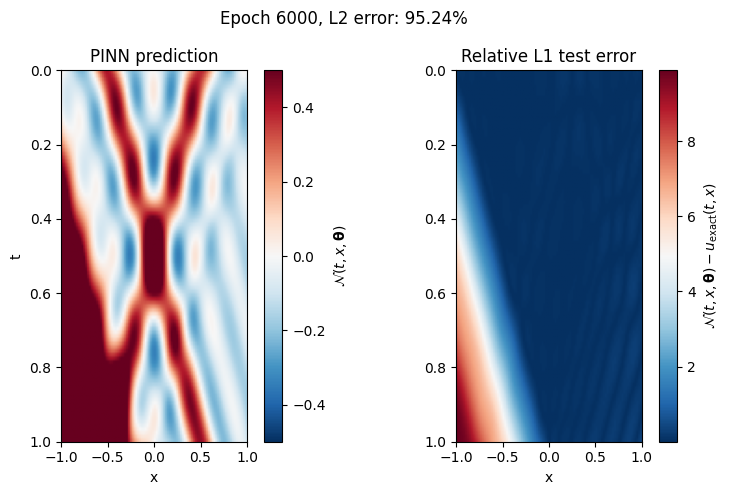

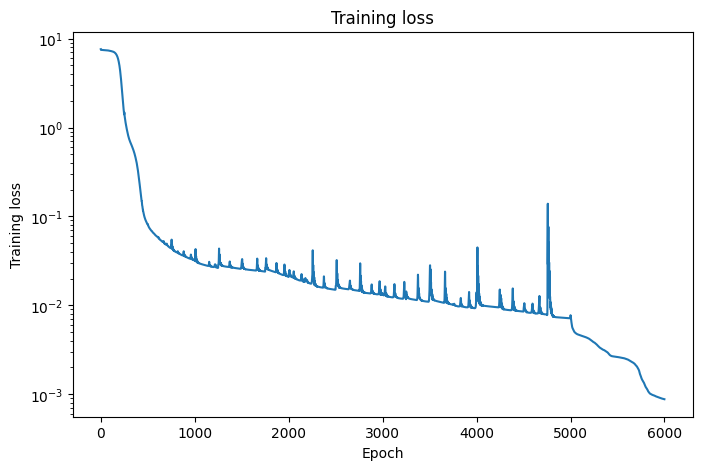

In [ ]:
# network parameters
layers = 2
neurons = 100
lr_adam = 1e-3
lr_lbfgs = 1e-1
epochs = 20000
ic_weight, left_bc_weight, right_bc_weight, velocity_bc_weight, pde_weight = 1.0, 1.0, 1.0, 1.0, 1.0

# optimiser switching
phase = "adam" # start with adam
switch = True # perform switch?
switch_point = 5000 # epoch to switch at

# resampling setup
resample = True
resample_period = 250

# =======================================================================================================

# seed for reproducibility
set_seed()

# create the model
pinn = PINN(n_layers=layers, n_neurons=neurons).to(device)

# get our collocation points
t_physics, x_physics, t_ic, x_ic, t_left, x_left, t_right, x_right, t_vel, x_vel = collocation_points(seed=42)

# define the test grid and exact solution on that grid
t_test = torch.linspace(t_0, t_N, 100).to(device)
x_test = torch.linspace(x_0, x_I, 100).to(device)

# define the optimiser
adam = torch.optim.Adam(pinn.parameters(), lr=lr_adam)
lbfgs = torch.optim.LBFGS(pinn.parameters(), lr=lr_lbfgs, line_search_fn="strong_wolfe")

# setup loss plots
tot_loss = 0
history = []

# torch LBFGS requires a closure() function
def closure():
    lbfgs.zero_grad()
    ic_loss = loss_ic(pinn, t_ic, x_ic)
    left_loss = loss_left(pinn, t_left, x_left)
    right_loss = loss_right(pinn, t_right, x_right)
    velocity_loss = loss_velocity(pinn, t_vel, x_vel)
    pde_loss = loss_pde(pinn, t_physics, x_physics)
    loss = (ic_weight * ic_loss) + (left_bc_weight * left_loss) + (right_bc_weight * right_loss) + (velocity_bc_weight * velocity_loss) + (pde_weight * pde_loss)
    loss.backward()
    return loss

# setup wandb
wandb.init(
    project="odil-pinn",
    name="resampling-adam-lbfgs-100neurons",
    config={
        "optimiser-main": "Adam",
        "lr-main": lr_adam,
        "optimiser-secondary": "L-BFGS",
        "lr-secondary": lr_lbfgs,
        "switch": "yes" if switch else "no",
        "switch_point": switch_point,
        "activation": "tanh",
        "hidden_layers": layers,
        "hidden_dim": neurons,
        "seed": 42,
        "resample": resample,
        "resample-period": resample_period, 
        "epochs": epochs,
        "pde_weight": pde_weight,
        "ic_weight": ic_weight,
        "left_bc_weight": left_bc_weight,
        "right_bc_weight": right_bc_weight,
        "velocity_bc_weight": velocity_bc_weight,
    }
)

start = time.time()
for i in range(epochs):
    # dynamic resampling
    if resample and i % resample_period == 0 and phase == "adam":
        t_physics, x_physics, t_ic, x_ic, t_left, x_left, t_right, x_right, t_vel, x_vel = collocation_points(seed=i) # seed differently each time for random resampling
        
    if switch and i == switch_point:
      phase = 'lbfgs'
    if phase == "adam":
      adam.zero_grad() # zero gradients on the graph

      # evaluate losses
      ic_loss = loss_ic(pinn, t_ic, x_ic)
      left_loss = loss_left(pinn, t_left, x_left)
      right_loss = loss_right(pinn, t_right, x_right)
      velocity_loss = loss_velocity(pinn, t_vel, x_vel)
      pde_loss = loss_pde(pinn, t_physics, x_physics)

      loss = (ic_weight * ic_loss) + (left_bc_weight * left_loss) + (right_bc_weight * right_loss) + (velocity_bc_weight * velocity_loss) + (pde_weight * pde_loss)

      # backpropagate and take optimiser step
      loss.backward()
      adam.step()

    elif phase == "lbfgs":
      loss = lbfgs.step(closure)

      with torch.enable_grad():
        ic_loss = loss_ic(pinn, t_ic, x_ic)
        left_loss = loss_left(pinn, t_left, x_left)
        right_loss = loss_right(pinn, t_right, x_right)
        velocity_loss = loss_velocity(pinn, t_vel, x_vel)
        pde_loss = loss_pde(pinn, t_physics, x_physics)

    history.append(loss.item())

    if ((i + 1) % 500 == 0) or (i == 0):
        clear_output(wait=True)
        training_plot(pinn, x_test, t_test, i)
        plot_loss(history)
        plt.show()

    if i % 100 == 0:
        wandb.log({
            "epoch": i,
            "loss/total": loss.item(),
            "loss/pde": pde_loss.item(),
            "loss/ic": ic_loss.item(),
            "loss/left_bc": left_loss.item(),
            "loss/right_bc": right_loss.item(),
            "loss/velocity_bc": velocity_loss.item(),
            "elapsed_time": time.time() - start,
            "phase": phase
        })

# cleanup logging
wandb.finish()

end = time.time()

print("Training duration:", end-start)